In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
from funs.prep_class import (
    EmulatedDataStorage,
    CaseDirectory,
    DataPrep,
    FeatureBuilder,
    Prep_Mask_Generation,
    visualize_emulation,
    meta_one_hot_shot,
)

%run /glade/u/home/qingyuany/repos/spatialtuning/funs/prep_class.py


In [3]:
working_dir = '/glade/work/qingyuany/camml_re'
case_name = "test"


#dict for cam7
# obs_dict = {'RESTOM': 'toa_net_all_mon',
#  'FSNT': 'fsnt',
#  'FLNT': 'toa_lw_all_mon',
#  'SWCF': 'toa_cre_sw_mon',
#  'LWCF': 'toa_cre_lw_mon',
#  'PRECT': 'PRECT',
#  'TGCLDLWP': 'TGCLDLWP',
#  'FSNTC': 'toa_sw_clr_t_mon',
#  'FLUTC': 'toa_lw_clr_t_mon',
#  'TMQ': 'PREH2O',
#  'LHFLX': 'LHFLX'}


#dict for camml:
#
obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "clwp", "TMQ": "pwv",
          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}


In [22]:
ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v1_b/post_simulations/batch_v1_b.nc")
#ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/initial_ppe.nc")
#obs = xr.open_dataset("/glade/work/qingyuany/camml_re/obs.nc")

obs = xr.open_dataset("~/satellite_obs/obs_interp_cam6.nc")
obs['pr'] = obs['pr']/(1000 * 86400)


In [21]:
#ppe = None

In [23]:
# para = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc")
# para = para.to_dataframe().drop(columns = 'Sample_nmb')
# para.index = para.index +1
para = pd.read_csv("/glade/work/qingyuany/camml_re/v1_b/post_simulations/paras.csv", index_col=0)



In [24]:
# import numpy as np

# x = arr["model_precip"]
# qs = [0.9, 0.95, 0.99]

# out = np.empty((x.shape[0], len(qs)), dtype=np.float32)

# batch = 16  # tune: 8, 16, 32...
# for i in range(0, x.shape[0], batch):
#     slab = x[i:i+batch].astype(np.float32, copy=False)
#     out[i:i+batch] = np.quantile(slab, qs, axis=(1,2)).T

# ppe_precip_freq = out
# ppe_precip_freq = pd.DataFrame(ppe_precip_freq, columns=['precip090', 'precip095', 'precip099'])
# ppe_precip_freq.index = ppe_precip_freq.index + 1
# ppe_precip_freq.to_csv('/glade/work/qingyuany/camml_re/v0/ppe_precip_freq.csv')
#ppe_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v1/post_simulations/added_precip.csv', index_col=0)
ppe_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v1_b/post_simulations/added_precip.csv', index_col=0)

In [25]:
# obs_precip_freq = np.quantile(arr['imerg_precip'], [0.9, 0.95, 0.99], axis = (0,1))
# obs_precip_freq = pd.Series(obs_precip_freq, index = ['precip090', 'precip095', 'precip099'])
# obs_precip_freq.to_csv('/glade/work/qingyuany/camml_re/v0/obs_precip_freq.csv')

obs_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v0/obs_precip_freq.csv', index_col = 0)
obs_precip_freq = obs_precip_freq.iloc[:,0]

In [26]:
obs_precip_freq

precip090     5.162430
precip095    11.337731
precip099    32.919077
Name: 0, dtype: float64

In [27]:
ppe_precip_freq.describe()

,precip090,precip095,precip099
count,100.000000,100.000000,100.000000
mean,5.950969,12.541856,36.645117
std,0.467702,0.735680,2.325577
min,4.843601,10.974443,31.721556
25%,5.667825,12.070564,35.107723
50%,5.878259,12.337216,36.272415
75%,6.306081,12.935866,38.575172
max,7.015680,14.826153,41.951106


In [28]:
lat_bins = np.arange(-75, 76, 5)  # -90 to 90 every 10 degrees

In [29]:
lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))

In [30]:
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359


In [31]:
test_case = Prep_Mask_Generation(working_dir, case_name, ppe, obs, obs_dict, para, lat_bins, manul_ppe_info, [ppe_precip_freq, obs_precip_freq])

Parameter and simulation indices match
nan variables matching between obs and simulation
Added data index matching
Zonalized and manually selected obs and ppe written as csv


In [32]:
test_case.sensitivity_emulation(n_cpus = 10)
test_case.mask_generation()

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [33]:
meta_table = meta_one_hot_shot(test_case.meta, test_case.data_gcm.para_nm)

In [34]:
meta_table.shape

(213, 34)

In [35]:
meta_table

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
SWCF_zonal_-75to-70,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
SWCF_zonal_-70to-65,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
SWCF_zonal_-65to-60,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
SWCF_zonal_-60to-55,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
SWCF_zonal_-55to-50,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FSNTOA_zonal_70to75,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
PRECT_4_7_1_359,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
precip090,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
precip095,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


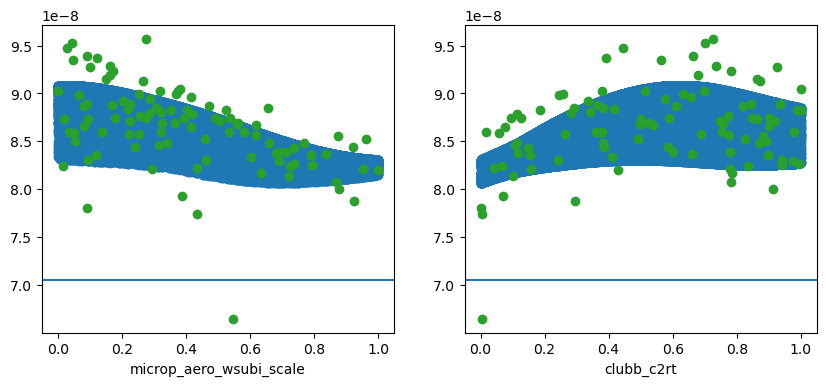

In [43]:
test_case.visualize_check('PRECT_zonal_5to10')

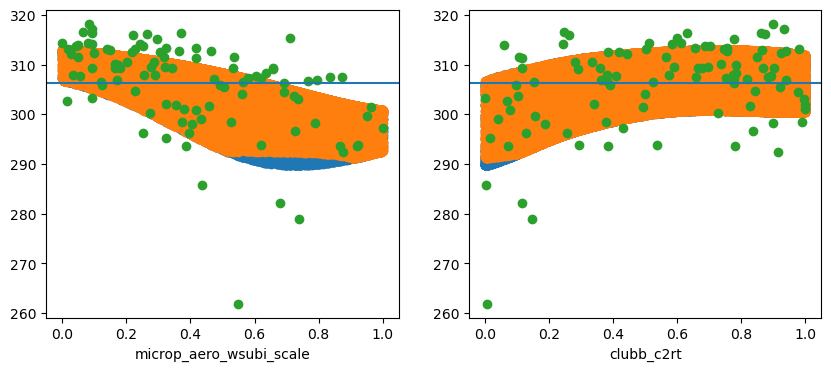

In [40]:
test_case.visualize_check('FSNTOA_zonal_15to20')

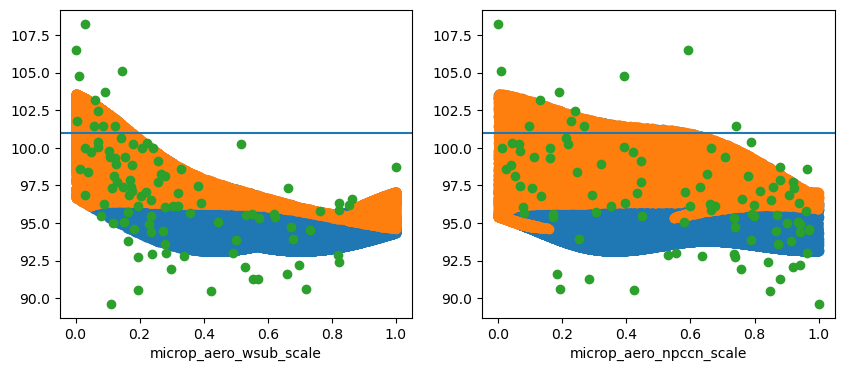

In [101]:
test_case.visualize_check('FSNTOA_zonal_65to75')

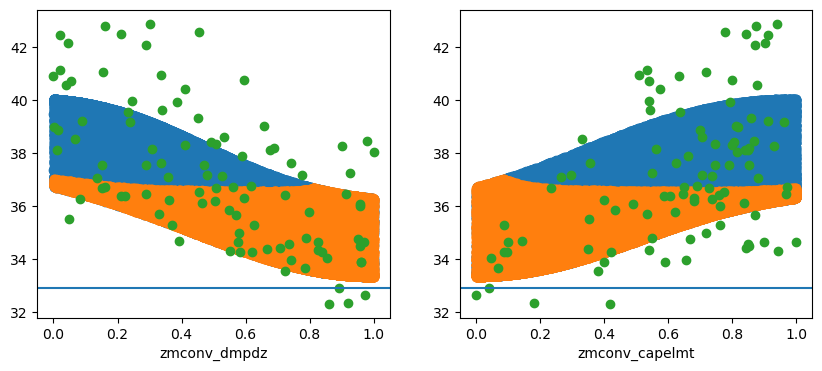

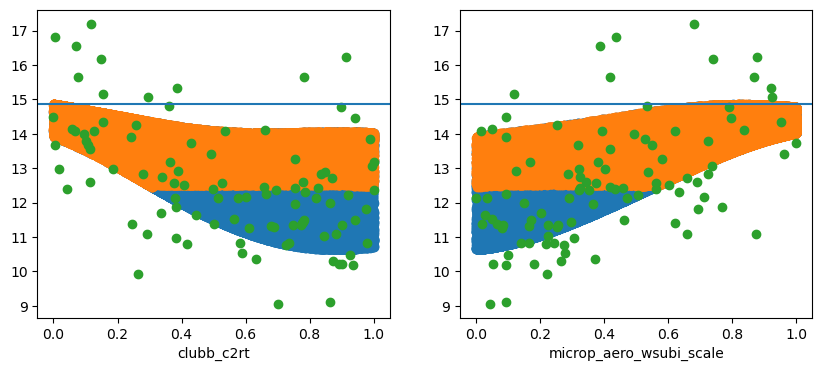

In [44]:
test_case.visualize_check('LWCF_zonal_70to75')

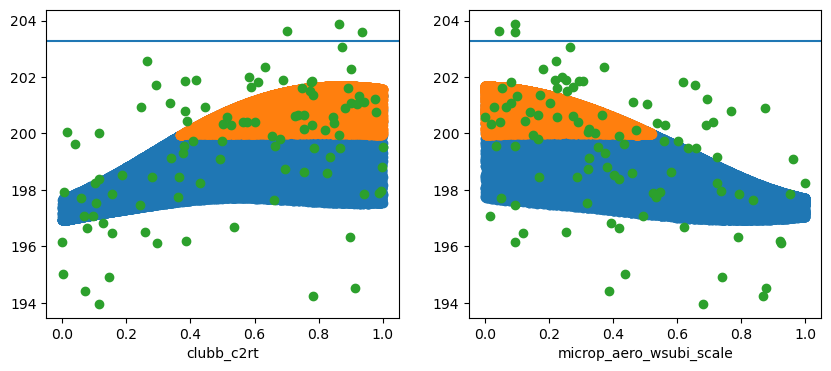

In [46]:
test_case.visualize_check('FLUT_zonal_65to70')